In [2]:
import sympy as sp

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def solve_theta_c():
    # Define symbols
    theta_c, rc, gamma = sp.symbols('theta_c rc gamma', real=True, positive= True)
    
    # Define the function f
    f = 1 + theta_c * (9*theta_c + 3) / (3*theta_c + 2)
    
    # Define the main equation
    equation = sp.Eq(gamma * theta_c / (f + theta_c) , 1 / (2*rc - 3))
    
    # Substitute gamma value
    #equation = equation.subs(gamma, (4/3))
    
    # Solve for theta
    solutions = sp.solve(equation, theta_c)
    
    # Simplify solutions
    simplified_solutions = [sp.simplify(sol) for sol in solutions]
    
    return simplified_solutions
    
solutions_symbolic = solve_theta_c()
for i, sol in enumerate(solutions_symbolic):
    print(f"theta_c = {sol}")



theta_c = (2*gamma*rc - 3*gamma - sqrt(-(-2*gamma*rc + 3*gamma + 4)*(2*gamma*rc - 3*gamma + 2)) - 4)/(3*(-2*gamma*rc + 3*gamma + 4))
theta_c = (2*gamma*rc - 3*gamma + sqrt(-(-2*gamma*rc + 3*gamma + 4)*(2*gamma*rc - 3*gamma + 2)) - 4)/(3*(-2*gamma*rc + 3*gamma + 4))


In [5]:
def get_rc_for_E( E , gamma ):
    # Define symbols
    theta_c, rc = sp.symbols('theta_c rc', real=True, positive= True)
    
    # Define the function f
    f = 1 + theta_c * (9*theta_c + 3) / (3*theta_c + 2)
    
    # Define the main equation
    equation1 = sp.Eq(gamma * theta_c / (f + theta_c) , 1 / (2*rc - 3))
    
    # Solve for theta
    solutions1 = sp.solve(equation1, theta_c)
    
    # Simplify solutions
    simplified_solutions1 = [sp.simplify(sol) for sol in solutions1]

    theta_c = simplified_solutions1[1]
    
    factor = sp.sqrt((1 - 2/rc)/(1 - (1/(2*rc - 3))))

    # Define the function f
    f = 1 + theta_c * (9*theta_c + 3) / (3*theta_c + 2)

    equation2 = sp.Eq( E , (f + theta_c)*factor)

    # Solve for rc
    solutions2 = sp.solve(equation2, rc)
    
    # Simplify solutions
    simplified_solutions2 = [sp.simplify(sol) for sol in solutions2]
    print(simplified_solutions2[0])

get_rc_for_E(1.05 , 4/3)
    

9.04183674598329


## Using h = 1/(1 - N a^2)  whera a is the sound speed

In [13]:
def find_root_newton(E_val, gamma_val, r0=4.0, tol=1e-8, max_iter=1000):
    N_val = 1/(gamma_val -1)
    r = sp.symbols('r', real=True, positive=True)

    numerator = sp.sqrt((1 - 2/r) / (1 - 1/(2*r - 3)))
    denominator = 1 - N_val / (2*r - 3)
    f_expr = numerator / denominator - E_val

    f_prime_expr = sp.diff(f_expr, r)

    f = sp.lambdify(r, f_expr, modules='numpy')
    f_prime = sp.lambdify(r, f_prime_expr, modules='numpy')

    r_curr = r0
    for _ in range(max_iter):
        f_val = f(r_curr)
        f_prime_val = f_prime(r_curr)

        if f_prime_val == 0:
            raise ValueError("Zero derivative. No convergence.")

        r_next = r_curr - f_val / f_prime_val

        if abs(r_next - r_curr) < tol:
            break

        r_curr = r_next
    else:
        raise ValueError("Newton-Raphson did not converge.")

    r_curr = float(r_curr) 
    v_c = np.sqrt(1 / (2*r_curr - 3))

    return r_curr, float(v_c)

r_crit, v_c = find_root_newton(E_val=1.05, gamma_val = 4/3)
print(f"Critical point: r = {r_crit:.6f}, v_c = {v_c:.6f}")

Critical point: r = 18.904801, v_c = 0.169492


In [15]:
def get_Theta_c_for_r_c(gamma, r_c_val):
    # Define symbols
    theta_c, rc = sp.symbols('theta_c rc', real=True, positive=True)
    
    # Define the function f
    f = 1 + theta_c * (9*theta_c + 3) / (3*theta_c + 2)
    
    # Define the main equation
    equation1 = sp.Eq(gamma * theta_c / (f + theta_c), 1 / (2*rc - 3))
    
    # Solve for theta
    solutions1 = sp.solve(equation1, theta_c)
    
    # Simplify solutions
    simplified_solutions1 = [sp.simplify(sol) for sol in solutions1]

    # Get theta_c expression (don't reassign the symbol)
    theta_c_expr = simplified_solutions1[1]
    
    # Now substitute r_c_solution into theta_c_expr to get the corresponding theta_c value
    theta_c_value = theta_c_expr.subs(rc, r_c_val)
    
    return theta_c_value

# Test the function
theta_c = get_Theta_c_for_r_c(4/3, 18.904801)
print(f"theta_c = {theta_c}")


theta_c = 0.0227981527050571


E = 1.01 → r_c = 79.07048399344936, v_c = 0.00489371599173892 , theta_c = 0.00489371599173892
E = 1.01 → r_c = 54.045651979713206, v_c = 0.00726714801385429 , theta_c = 0.00726714801385429
E = 1.02 → r_c = 41.5222239030364, v_c = 0.00959650122162353 , theta_c = 0.00959650122162353
E = 1.02 → r_c = 34.000067423773146, v_c = 0.0118848725889183 , theta_c = 0.0118848725889183
E = 1.03 → r_c = 28.97906763953502, v_c = 0.0141350007943984 , theta_c = 0.0141350007943984
E = 1.03 → r_c = 25.387695639233737, v_c = 0.0163493218940815 , theta_c = 0.0163493218940815
E = 1.04 → r_c = 22.69014898425156, v_c = 0.0185300143570469 , theta_c = 0.0185300143570469
E = 1.04 → r_c = 20.588730789068645, v_c = 0.0206790358116796 , theta_c = 0.0206790358116796
E = 1.05 → r_c = 18.90480054240792, v_c = 0.0227981533399811 , theta_c = 0.0227981533399811
E = 1.05 → r_c = 17.524660314407537, v_c = 0.0248889685921570 , theta_c = 0.0248889685921570
E = 1.06 → r_c = 16.37249742666088, v_c = 0.0269529388195524 , theta_c

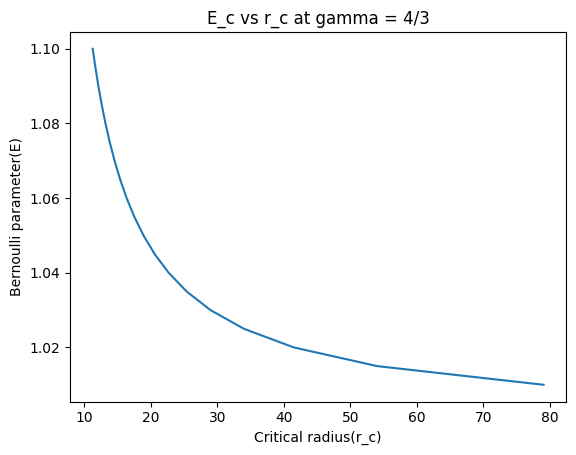

In [30]:
gamma = 4/3
E_values = np.arange(1.01, 1.1, 0.005)
rc_values = []
theta_values = []
results = {}

for E in E_values:
    rc, v_c = find_root_newton(E, gamma)
    theta_c = get_Theta_c_for_r_c(gamma, rc)
    rc_values.append(rc if rc else np.nan)
    theta_values.append(theta_c if theta_c else np.nan)
    vc = 1/(2*rc - 3)**0.5
    
    results[E] = [rc, vc, theta_c]
    
    print(f"E = {E:.2f} → r_c = {rc}, v_c = {theta_c} , theta_c = {theta_c}")

plt.plot(rc_values,E_values)
plt.xlabel("Critical radius(r_c)")
plt.ylabel("Bernoulli parameter(E)")
plt.title("E_c vs r_c at gamma = 4/3")
plt.savefig("E_c_vs_r_c.png")



In [18]:
def compute_dvdr_and_dTdr_c(T_c , gamma_val, r_c):
    
    v_c = 1/np.sqrt(2*r_c - 3)
    a_c = v_c
    a_c2 = a_c**2
    X , Y , Z , T, N = sp.symbols('X Y Z T N' , real = True)
    gamma = 1 + (1/ N)
    f = 1 + T*(9*T + 3)/(3*T + 2)
    a2 = gamma * T/(f + T)
    factor = sp.diff(a2, T).subs(T, T_c)

    eqn3 = sp.Eq(X*r_c*(r_c - 2)*(2*X - Y/a_c) , (1-a_c2)*((Y/a_c2) + 2*a_c2))
    
    eqn3_sub = eqn3.subs(Y, gamma * Z * factor)

    eqn_final = eqn3_sub.subs(Z, -(T_c/N)*((1/(a_c2*r_c*(r_c-2))) - X/(a_c*(1 - a_c2))))

    # Rearrange eqn_final to polynomial form in X
    lhs, rhs = eqn_final.lhs - eqn_final.rhs, 0
    poly = sp.expand(lhs)
    # Collect terms by X
    poly = sp.collect(poly, X)
    # Get polynomial coefficients
    p = sp.Poly(poly, X)
    
    print("Quadratic in X:")
    print(f"A = {p.coeff_monomial(X**2)}")
    print(f"B = {p.coeff_monomial(X)}")
    print(f"C = {p.coeff_monomial(1)}")
    print(f"Equation: {p.as_expr()} = 0")

    eqn_final = eqn_final.subs(N, 3)
    X_solution = sp.solve(eqn_final, X)

    print("ac^2" , a_c*a_c)
    return X_solution

X_solution = compute_dvdr_and_dTdr_c(0.0227981533399811, 4/3, 18.90480054240792)
# Print the solution(s) for X
for sol in X_solution:
    print(sol)



Quadratic in X:
A = 1.0*(639.163764926822*N**3 - 232.964553997306*N**2 - 465.929107994612*N - 232.964553997306)/N**3
B = 1.0*(8.88178419700125e-16*N**2 + 1.77635683940025e-15*N + 8.88178419700125e-16)/N**3
C = 1.0*(-0.0558048505772631*N**3 + 0.0749042729647158*N**2 + 0.149808545929432*N + 0.0749042729647158)/N**3
Equation: 1.0*X**2*(639.163764926822*N**3 - 232.964553997306*N**2 - 465.929107994612*N - 232.964553997306)/N**3 + 1.0*X*(8.88178419700125e-16*N**2 + 1.77635683940025e-15*N + 8.88178419700125e-16)/N**3 + 1.0*(-0.0558048505772631*N**3 + 0.0749042729647158*N**2 + 0.149808545929432*N + 0.0749042729647158)/N**3 = 0
ac^2 0.02872770640385782
-0.00477322271693302
0.00477322271693303


Solving Bondi accretion for POSITIVE derivative at sonic point...
Starting from sonic point: r=18.90480054240792, v=0.1694924966004626, Θ=0.0227981533399811, dvdr_sign=1
Integrating inward to horizon...
Integrating outward to large radius...

Solving Bondi accretion for NEGATIVE derivative at sonic point...
Starting from sonic point: r=18.90480054240792, v=0.1694924966004626, Θ=0.0227981533399811, dvdr_sign=-1
Integrating inward to horizon...
Integrating outward to large radius...
Positive derivative solution: 1049 points
Negative derivative solution: 1049 points

=== POSITIVE DERIVATIVE CASE ===
At r_min = 2.500: v = 0.009804, Θ = 0.283095
At r_max = 1000.000: v = 0.287424, Θ = 0.001323
Mach number range: [0.022, 6.855]

=== NEGATIVE DERIVATIVE CASE ===
At r_min = 2.500: v = 0.849729, Θ = 0.051700
At r_max = 1000.000: v = 0.000376, Θ = 0.012273
Mach number range: [0.003, 3.448]


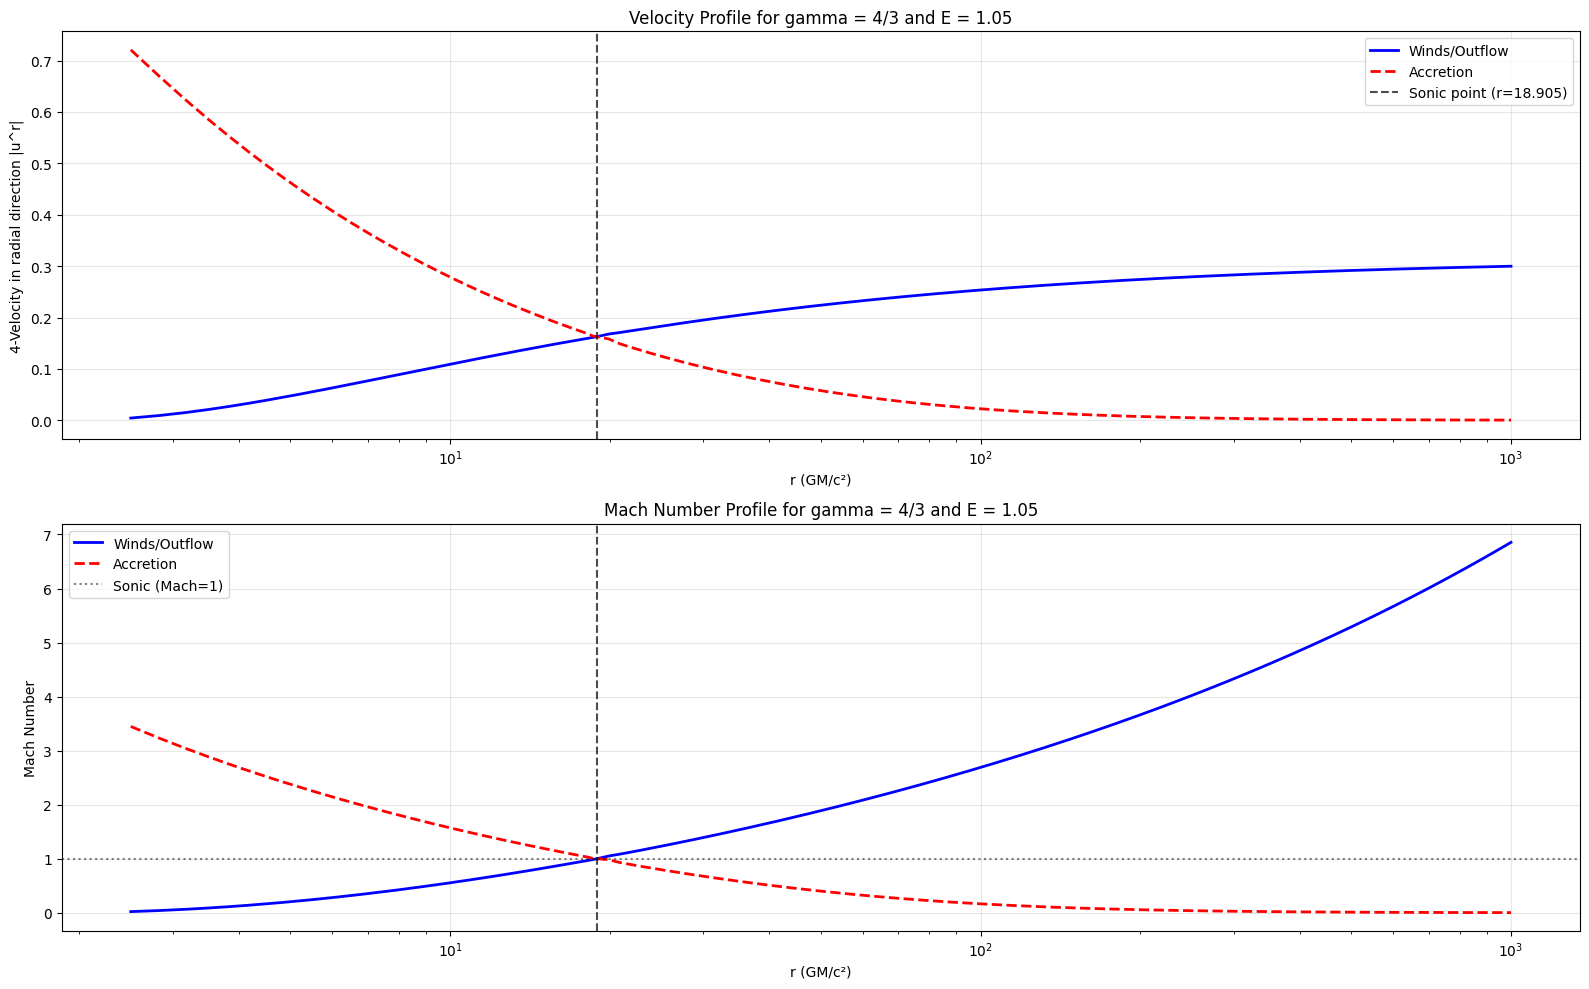

In [33]:

def bondi_equations(r, y, Gamma, N, stp, dvdr_sign=1):
    """
    Coupled ODEs for relativistic Bondi accretion
    y = [v, Theta] where v = velocity, Theta = temperature
    dvdr_sign: +1 for positive derivative, -1 for negative derivative at sonic point
    """
    v, Theta = y
    f = 1 + Theta*(9*Theta + 3)/(3*Theta + 2)
    
    # Equation (7a): dv/dr
    if(stp != 0):
        # Sound speed squared (assuming ideal gas)
        a2 = Gamma * Theta/(f+Theta)
        numerator_v = (1 - v**2) * (a2 * (2*r - 3) - 1)
        denominator_v = r * (r - 2) * (v - a2/v)
        dvdr = numerator_v / denominator_v
        
    else:
        a2 = v * v
        # Use the sign parameter to choose derivative direction
        dvdr = dvdr_sign * 0.00477322271693303
    
    # Equation (7b): dTheta/dr  
    term1 = (2*r - 3) / (r * (r - 2))
    term2 = (1 / (v * (1 - v**2))) * dvdr
    dThetadr = -(Theta / N) * (term1 + term2)
    
    return np.array([dvdr, dThetadr])

def rk4_step(f, r, y, h, *args):
    """
    Single RK4 step
    """
    k1 = h * f(r, y, *args)
    k2 = h * f(r + h/2, y + k1/2, *args)
    k3 = h * f(r + h/2, y + k2/2, *args)
    k4 = h * f(r + h, y + k3, *args)
    
    return y + (k1 + 2*k2 + 2*k3 + k4) / 6

def solve_from_sonic_point(r_sonic, v_sonic, Theta_sonic, Gamma=4/3, 
                          r_inner=2.5, r_outer=1000.0, n_steps=50000, dvdr_sign=1):
    """
    Solve Bondi accretion starting from known sonic point
    and integrating both inward and outward
    dvdr_sign: +1 for positive derivative, -1 for negative derivative at sonic point
    """
    N = 1 / (Gamma - 1)  # Polytropic index
    
    print(f"Starting from sonic point: r={r_sonic}, v={v_sonic}, Θ={Theta_sonic}, dvdr_sign={dvdr_sign}")
    
    # INWARD INTEGRATION (sonic point to horizon)
    n_in = 50
    r_inward = np.linspace(r_sonic, r_inner, n_in)
    h_in = (r_inner - r_sonic) / n_in  # Negative step
    
    v_inward = np.zeros(n_in)
    Theta_inward = np.zeros(n_in)
    
    y_current = np.array([v_sonic, Theta_sonic])
    v_inward[0] = v_sonic
    Theta_inward[0] = Theta_sonic
    
    print("Integrating inward to horizon...")
    for i in range(1, n_in):
        y_current = rk4_step(bondi_equations, r_inward[i-1], y_current, h_in, Gamma, N, i-1, dvdr_sign)
        v_inward[i] = y_current[0]
        Theta_inward[i] = y_current[1]
        
    
    # OUTWARD INTEGRATION (sonic point to large radius)
    n_out = 1000
    r_outward = np.linspace(r_sonic, r_outer, n_out)
    h_out = (r_outer - r_sonic) / n_out  # Positive step
    
    v_outward = np.zeros(n_out)
    Theta_outward = np.zeros(n_out)
    
    # Reset to sonic point conditions
    y_current = np.array([v_sonic, Theta_sonic])
    v_outward[0] = v_sonic
    Theta_outward[0] = Theta_sonic
    
    print("Integrating outward to large radius...")
    for i in range(1, n_out):
        y_current = rk4_step(bondi_equations, r_outward[i-1], y_current, h_out, Gamma, N, i-1, dvdr_sign)
        v_outward[i] = y_current[0]
        Theta_outward[i] = y_current[1]
    
    # Combine solutions (inward reversed + outward)
    r_combined = np.concatenate([r_inward[::-1], r_outward[1:]])
    v_combined = np.concatenate([v_inward[::-1], v_outward[1:]])
    Theta_combined = np.concatenate([Theta_inward[::-1], Theta_outward[1:]])
    
    return r_combined, v_combined, Theta_combined

# Example usage with your known sonic point values
if __name__ == "__main__":
    # YOUR KNOWN SONIC POINT VALUES 
    r_sonic = 18.90480054240792  
    v_sonic = 1/np.sqrt(2*r_sonic - 3)    
    Theta_sonic = 0.0227981533399811
    Gamma = 4/3
    
    print("Solving Bondi accretion for POSITIVE derivative at sonic point...")
    r_pos, v_pos, Theta_pos = solve_from_sonic_point(r_sonic, v_sonic, Theta_sonic, Gamma, dvdr_sign=1)
    
    print("\nSolving Bondi accretion for NEGATIVE derivative at sonic point...")
    r_neg, v_neg, Theta_neg = solve_from_sonic_point(r_sonic, v_sonic, Theta_sonic, Gamma, dvdr_sign=-1)
    
    print(f"Positive derivative solution: {len(r_pos)} points")
    print(f"Negative derivative solution: {len(r_neg)} points")

    # Calculate derived quantities for positive derivative case
    f_pos = 1 + Theta_pos*(9*Theta_pos + 3)/(3*Theta_pos + 2)
    mach_number_pos = v_pos / np.sqrt(Gamma * Theta_pos/ (f_pos + Theta_pos))
    sound_speed_pos = np.sqrt(Gamma * Theta_pos / (f_pos + Theta_pos))
    
    # Calculate derived quantities for negative derivative case
    f_neg = 1 + Theta_neg*(9*Theta_neg + 3)/(3*Theta_neg + 2)
    mach_number_neg = v_neg / np.sqrt(Gamma * Theta_neg/ (f_neg + Theta_neg))
    sound_speed_neg = np.sqrt(Gamma * Theta_neg / (f_neg + Theta_neg))
    
    # Create 4 plots with both solutions
    plt.figure(figsize=(16, 10))

    ur_pos = np.sqrt((1 - 2/r_pos)/(1 - v_pos**2))*v_pos
    ur_neg = np.sqrt((1 - 2/r_neg)/(1 - v_neg**2))*v_neg
    # Plot 1: Velocity vs r
    plt.subplot(2, 1, 1)
    plt.semilogx(r_pos, ur_pos, 'b-', linewidth=2, label='Winds/Outflow')
    plt.semilogx(r_neg, ur_neg, 'r--', linewidth=2, label='Accretion')
    plt.axvline(x=r_sonic, color='k', linestyle='--', alpha=0.7, 
                label=f'Sonic point (r={r_sonic:.3f})')
    plt.xlabel('r (GM/c²)')
    plt.ylabel('4-Velocity in radial direction |u^r|')
    plt.title('Velocity Profile for gamma = 4/3 and E = 1.05')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Mach number vs r
    plt.subplot(2, 1, 2)
    plt.semilogx(r_pos, mach_number_pos, 'b-', linewidth=2, label='Winds/Outflow')
    plt.semilogx(r_neg, mach_number_neg, 'r--', linewidth=2, label='Accretion')
    plt.axvline(x=r_sonic, color='k', linestyle='--', alpha=0.7)
    plt.axhline(y=1, color='k', linestyle=':', alpha=0.5, label='Sonic (Mach=1)')
    plt.xlabel('r (GM/c²)')  
    plt.ylabel('Mach Number')
    plt.title('Mach Number Profile for gamma = 4/3 and E = 1.05')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("SphericalAccretion.png")
    
    # Print diagnostics for both cases
    print(f"\n=== POSITIVE DERIVATIVE CASE ===")
    print(f"At r_min = {r_pos[0]:.3f}: v = {v_pos[0]:.6f}, Θ = {Theta_pos[0]:.6f}")
    print(f"At r_max = {r_pos[-1]:.3f}: v = {v_pos[-1]:.6f}, Θ = {Theta_pos[-1]:.6f}")
    print(f"Mach number range: [{mach_number_pos.min():.3f}, {mach_number_pos.max():.3f}]")
    
    print(f"\n=== NEGATIVE DERIVATIVE CASE ===")
    print(f"At r_min = {r_neg[0]:.3f}: v = {v_neg[0]:.6f}, Θ = {Theta_neg[0]:.6f}")
    print(f"At r_max = {r_neg[-1]:.3f}: v = {v_neg[-1]:.6f}, Θ = {Theta_neg[-1]:.6f}")
    print(f"Mach number range: [{mach_number_neg.min():.3f}, {mach_number_neg.max():.3f}]")